En suivant les étapes du [Kaggle sur la saisonalité](https://www.kaggle.com/code/ryanholbrook/seasonality)

Objectif: savoir quelle temporalité est pertinente.

In [2]:
import matplotlib.pyplot as plt

import seaborn as sns
import pandas as pd


# 1 : Exploration

## 1.2 Chargement et fusion des 12 fichiers

Remarque: la premiere ligne de chaque fichier est un titre texte (a ignorer).


In [ ]:
from src.data_treatment_prix_ecarts import build_df_all

df_all = build_df_all()

df_all.head()

# see daylight saving time, one day with 23 hours.
df_all[(df_all["Heure de début"]>=datetime.datetime(2025,3,30,1))&(df_all["Heure de début"]<=datetime.datetime(2025,3,30,4))]
df_all[(df_all["Heure de début"]>=datetime.datetime(2025,10,26,1))&(df_all["Heure de début"]<=datetime.datetime(2025,10,26,4))]


,file,rows,first_timestamp,month_from_data
0,MMA_HECAR_2025 (10).csv,2976,2025-01-01,2025-01
1,MMA_HECAR_2025 (9).csv,2688,2025-02-01,2025-02
2,MMA_HECAR_2025 (8).csv,2972,2025-03-01,2025-03
3,MMA_HECAR_2025 (7).csv,2880,2025-04-01,2025-04
4,MMA_HECAR_2025 (11).csv,2976,2025-05-01,2025-05
5,MMA_HECAR_2025 (6).csv,2880,2025-06-01,2025-06
6,MMA_HECAR_2025 (5).csv,2976,2025-07-01,2025-07
7,MMA_HECAR_2025 (4).csv,2976,2025-08-01,2025-08
8,MMA_HECAR_2025 (3).csv,2880,2025-09-01,2025-09
9,MMA_HECAR_2025 (2).csv,2980,2025-10-01,2025-10


,Heure de début,Heure de fin,Déséquilibre(MWh),Tendance,Prix de Règlements des Ecarts Positifs (Euros/MWh),Prix de Règlements des Ecarts Négatifs (Euros/MWh),source_file
0,2025-01-01 00:00:00,2025-01-01 00:15:00,577.68,BAISSE,20.34,23.28,MMA_HECAR_2025 (10).csv
1,2025-01-01 00:15:00,2025-01-01 00:30:00,190.33,BAISSE,19.22,22.00,MMA_HECAR_2025 (10).csv
2,2025-01-01 00:30:00,2025-01-01 00:45:00,201.93,BAISSE,32.13,36.79,MMA_HECAR_2025 (10).csv
3,2025-01-01 00:45:00,2025-01-01 01:00:00,338.08,BAISSE,29.13,33.35,MMA_HECAR_2025 (10).csv
4,2025-01-01 01:00:00,2025-01-01 01:15:00,1.81,BAISSE,13.24,15.16,MMA_HECAR_2025 (10).csv


# 1.2) Transform into UTC

In [ ]:
for col in ["Heure de début", "Heure de fin"]:
    s = pd.to_datetime(df_all[col], errors="raise")

    local = s.dt.tz_localize(
        "Europe/Paris",
        ambiguous="infer",   # handles the 25h day (duplicated 02:00-02:45)
        nonexistent="raise"  # good safety check for the 23h day
    )

    df_all[f"{col} (UTC)"] = local.dt.tz_convert("UTC")




# see that all dates now have 24 hours
df_all[(df_all["Heure de début (UTC)"]>=datetime.datetime(2025,10,26,0, tzinfo=datetime.UTC))&(df_all["Heure de début (UTC)"]<=datetime.datetime(2025,10,26,3, tzinfo=datetime.UTC))]


In [4]:
start_ts_col, end_ts_col = df_all.columns[:2]
price_cols = df_all.columns[-3:-1].tolist() if df_all.columns[-1] == 'source_file' else df_all.columns[-2:].tolist()

# Enforce numeric type for the 2 target price columns.
for col in price_cols:
    df_all[col] = pd.to_numeric(df_all[col], errors='coerce')

dt = df_all[start_ts_col]
df_all['month'] = dt.dt.month
df_all['month_name'] = dt.dt.month_name()
df_all['weekday_name'] = dt.dt.day_name()
df_all['weekday'] = dt.dt.weekday
df_all['hour'] = dt.dt.hour
df_all['minute'] = dt.dt.minute

# days within a week, from kaggle
df_all['week'] = dt.dt.isocalendar().week # the seasonal period (period)

# days within a year, from kaggle
df_all["dayofyear"] = dt.dt.dayofyear
df_all['year'] = dt.dt.year

# time within a day, emulated from kaggle
# x for seasonal plot: numeric minutes in day (safe for seaborn)
df_all["min_in_day"] = (
    df_all["Heure de début"].dt.hour * 60
    + df_all["Heure de début"].dt.minute
)

# numeric minutes in a week 
df_all["min_in_week"] = (
    df_all["Heure de début"].dt.weekday * 24 * 60
    + df_all["Heure de début"].dt.hour * 60
    + df_all["Heure de début"].dt.minute
)

# numeric minutes in a month 
df_all["min_in_month"] = (
    df_all["Heure de début"].dt.day * 24 * 60
    + df_all["Heure de début"].dt.hour * 60
    + df_all["Heure de début"].dt.minute
)

## 1.1 Représentation brute

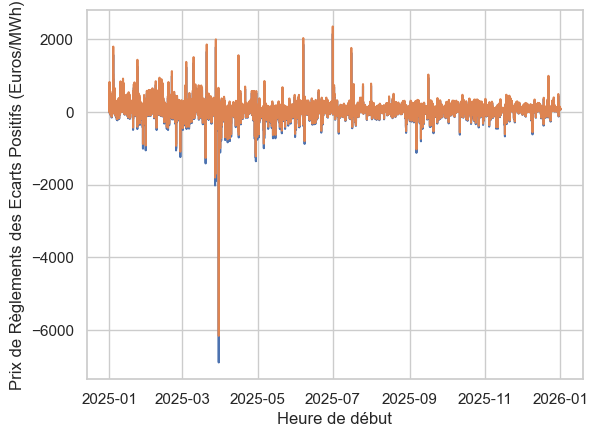

In [ ]:
# make an interactive plot
# import PyQt6
# %matplotlib qt

for price_col in ["Prix de Règlements des Ecarts Positifs (Euros/MWh)", "Prix de Règlements des Ecarts Négatifs (Euros/MWh)"]:
    sns.lineplot(data=df_all, x="Heure de début", y=price_col)


<Axes: xlabel='Heure de début', ylabel='Prix de Règlements des Ecarts Positifs (Euros/MWh)'>

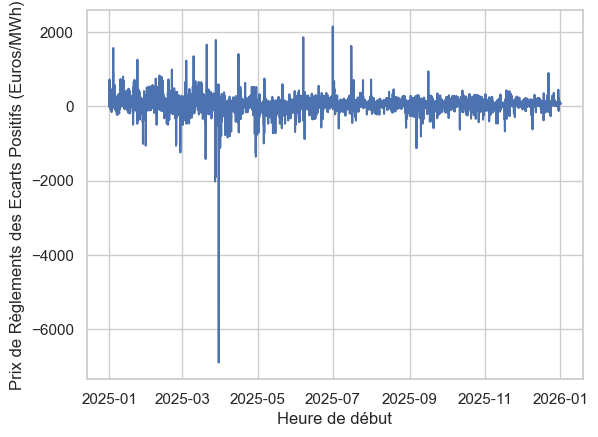

In [26]:


sns.lineplot(data=df_all, x="Heure de début", y="Prix de Règlements des Ecarts Positifs (Euros/MWh)")


Commentaire : à première vue, pas de saisonnalité. Mais plutôt un poids très fort à donnre au lag 1, la valeur du quart d'heure précédent, d'après ce qu'il y a dans le noteook 2.0

# 1.2 Seasonal plots

c:\Users\Loris Amabile\Documents\c_market\plots.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")


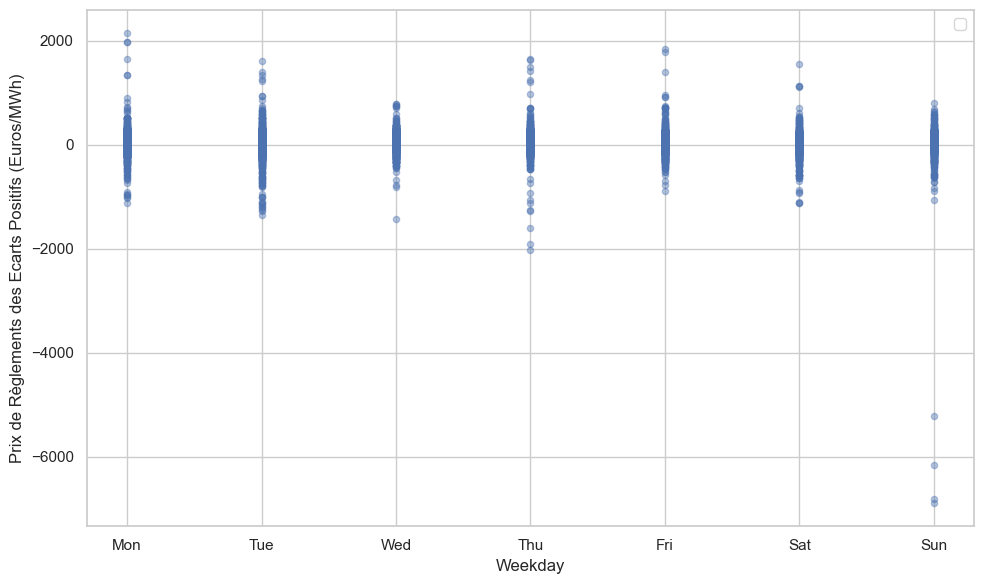

In [ ]:
from plots import plot_weekday_seasonal

plot_weekday_seasonal(df_all.set_index("Heure de début"), "Prix de Règlements des Ecarts Positifs (Euros/MWh)")

In [6]:
from plots import seasonal_plot


<Axes: title={'center': 'Seasonal Plot (year/dayofyear)'}, xlabel='dayofyear', ylabel='Prix de Règlements des Ecarts Positifs (Euros/MWh)'>

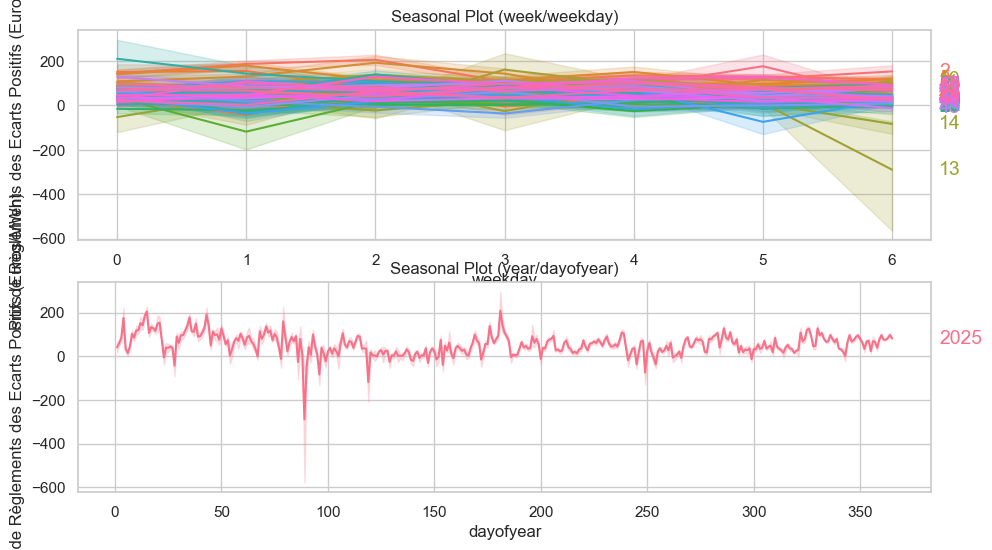

In [8]:

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(11, 6))
seasonal_plot(df_all, y="Prix de Règlements des Ecarts Positifs (Euros/MWh)", period="week", freq="weekday", ax=ax0)
seasonal_plot(df_all, y="Prix de Règlements des Ecarts Positifs (Euros/MWh)", period="year", freq="dayofyear", ax=ax1)

##
# TODO wait quelle valeur il prend là ? 
# Moi j'ai pas une seule valeur par jour, j'ai une par quart d'heure
# Où sont passées les valeurs à -6000?

# attention, si j'utilise period week et freq weekday, il va aggréger, et je ne sais pas comment. Est une moyenne ?

<Axes: title={'center': 'Seasonal Plot (year/dayofyear)'}, xlabel='dayofyear', ylabel='Prix de Règlements des Ecarts Négatifs (Euros/MWh)'>

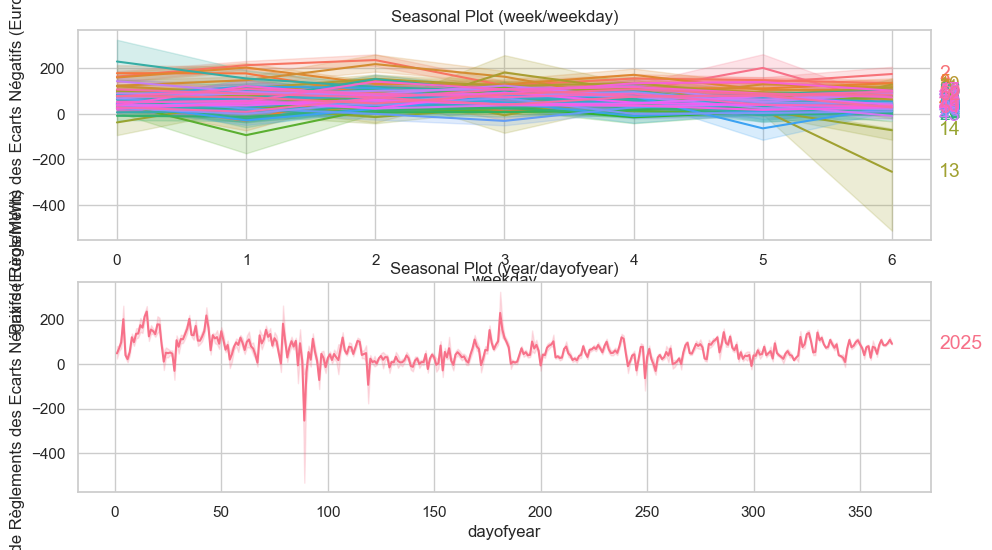

In [9]:
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(11, 6))
seasonal_plot(df_all, y="Prix de Règlements des Ecarts Négatifs (Euros/MWh)", period="week", freq="weekday", ax=ax0)
seasonal_plot(df_all, y="Prix de Règlements des Ecarts Négatifs (Euros/MWh)", period="year", freq="dayofyear", ax=ax1)

time within day

In [17]:
df_all.head()

,Heure de début,Heure de fin,Déséquilibre(MWh),Tendance,Prix de Règlements des Ecarts Positifs (Euros/MWh),Prix de Règlements des Ecarts Négatifs (Euros/MWh),source_file,month,month_name,weekday_name,weekday,hour,minute,week,dayofyear,year,min_in_day,min_in_week,min_in_month
0,2025-01-01 00:00:00,2025-01-01 00:15:00,577.68,BAISSE,20.34,23.28,MMA_HECAR_2025 (10).csv,1,January,Wednesday,2,0,0,1,1,2025,0,2880,1440
1,2025-01-01 00:15:00,2025-01-01 00:30:00,190.33,BAISSE,19.22,22.00,MMA_HECAR_2025 (10).csv,1,January,Wednesday,2,0,15,1,1,2025,15,2895,1455
2,2025-01-01 00:30:00,2025-01-01 00:45:00,201.93,BAISSE,32.13,36.79,MMA_HECAR_2025 (10).csv,1,January,Wednesday,2,0,30,1,1,2025,30,2910,1470
3,2025-01-01 00:45:00,2025-01-01 01:00:00,338.08,BAISSE,29.13,33.35,MMA_HECAR_2025 (10).csv,1,January,Wednesday,2,0,45,1,1,2025,45,2925,1485
4,2025-01-01 01:00:00,2025-01-01 01:15:00,1.81,BAISSE,13.24,15.16,MMA_HECAR_2025 (10).csv,1,January,Wednesday,2,1,0,1,1,2025,60,2940,1500


<Axes: title={'center': 'Seasonal Plot (weekday/min_in_day)'}, xlabel='min_in_day', ylabel='Prix de Règlements des Ecarts Négatifs (Euros/MWh)'>

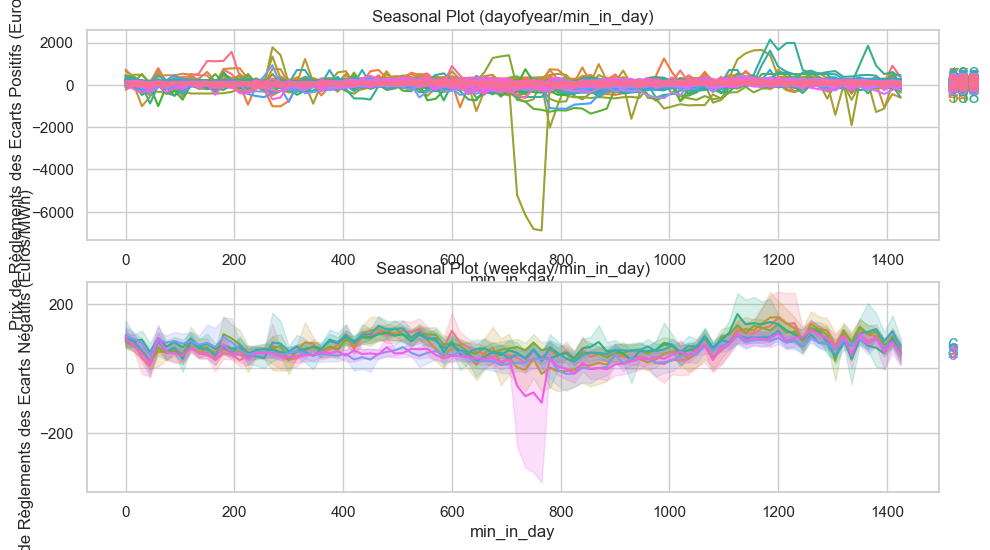

In [16]:
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(11, 6))
seasonal_plot(df_all, y="Prix de Règlements des Ecarts Positifs (Euros/MWh)", period="dayofyear", freq="min_in_day", ax=ax0)
seasonal_plot(df_all, y="Prix de Règlements des Ecarts Négatifs (Euros/MWh)", period="weekday", freq="min_in_day", ax=ax1)

In [ ]:
# useless, min_in_week et min_in_month n'apportent aucune info
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(11, 6))
seasonal_plot(df_all, y="Prix de Règlements des Ecarts Positifs (Euros/MWh)", period="week", freq="min_in_week", ax=ax0)
seasonal_plot(df_all, y="Prix de Règlements des Ecarts Négatifs (Euros/MWh)", period="month", freq="min_in_week", ax=ax1)
seasonal_plot(df_all, y="Prix de Règlements des Ecarts Négatifs (Euros/MWh)", period="month", freq="min_in_month", ax=ax2)

<Axes: title={'center': 'Seasonal Plot (month/min_in_day)'}, xlabel='min_in_day', ylabel='Prix de Règlements des Ecarts Positifs (Euros/MWh)'>

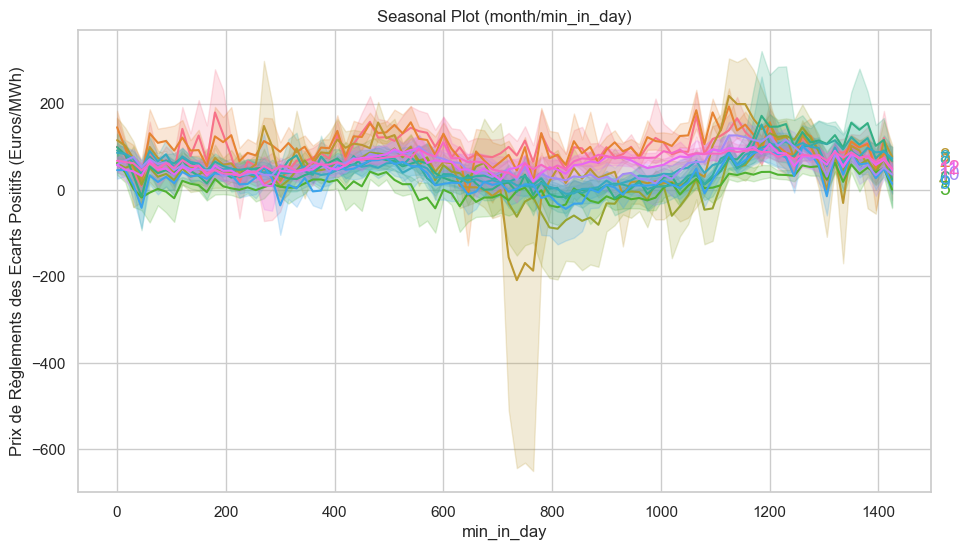

In [ ]:
fig, (ax0) = plt.subplots(1, 1, figsize=(11, 6))
seasonal_plot(df_all, y="Prix de Règlements des Ecarts Positifs (Euros/MWh)", period="month", freq="min_in_day", ax=ax0)

# ici ça nous dit : en moyenne, le profil pour un jour de mars, ou de décembre, c'est ça. 
# Peut-on les grouper, par saison par exemple ?

<Axes: title={'center': 'Seasonal Plot (month/min_in_day)'}, xlabel='min_in_day', ylabel='Prix de Règlements des Ecarts Positifs (Euros/MWh)'>

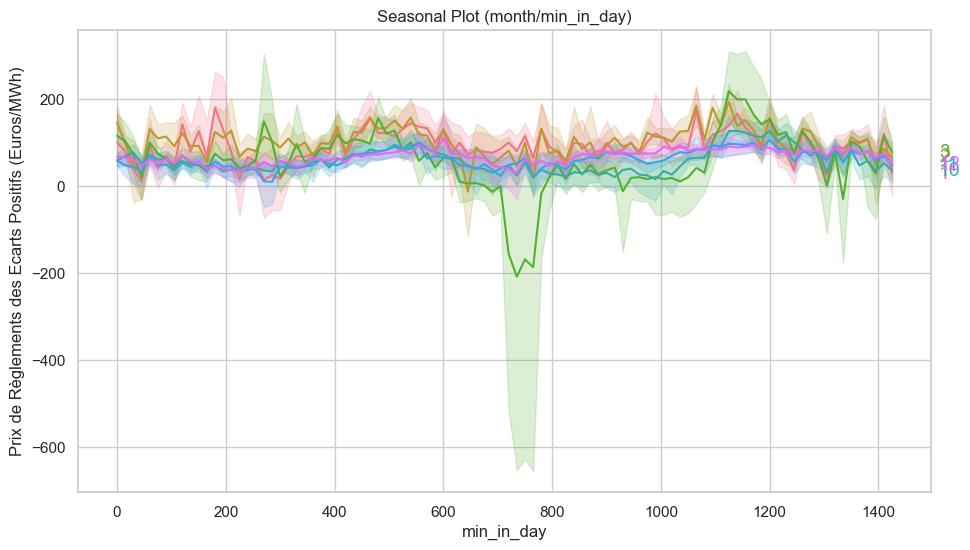

In [20]:
# tracer la meme chose, mais juste pour les mois d'hiver
fig, (ax0) = plt.subplots(1, 1, figsize=(11, 6))
seasonal_plot(df_all[df_all["month"].isin([1,2,3,10,11,12])], y="Prix de Règlements des Ecarts Positifs (Euros/MWh)", period="month", freq="min_in_day", ax=ax0)

<Axes: title={'center': 'Seasonal Plot (month/min_in_day)'}, xlabel='min_in_day', ylabel='Prix de Règlements des Ecarts Positifs (Euros/MWh)'>

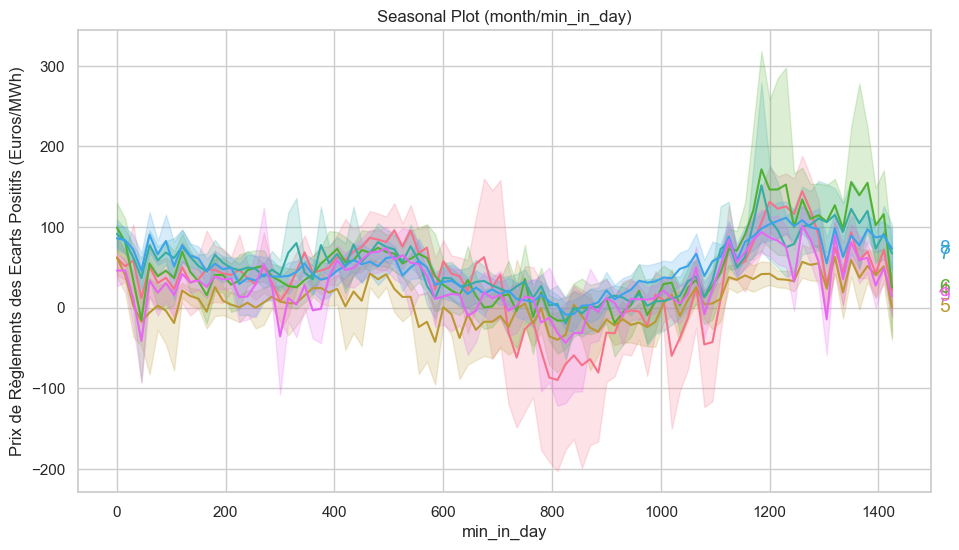

In [21]:
# tracer la meme chose, mais juste pour les mois d'été
fig, (ax0) = plt.subplots(1, 1, figsize=(11, 6))
seasonal_plot(df_all[df_all["month"].isin([4,5,6,7,8,9])], y="Prix de Règlements des Ecarts Positifs (Euros/MWh)", period="month", freq="min_in_day", ax=ax0)

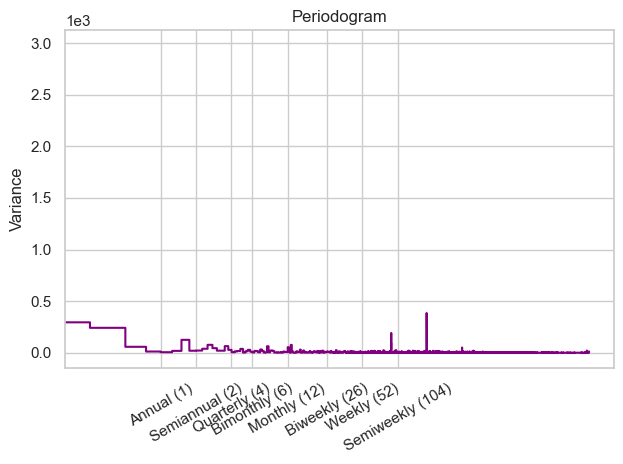

In [22]:
from plots import plot_periodogram

plot_periodogram(df_all["Prix de Règlements des Ecarts Positifs (Euros/MWh)"])

Possible que la conclusion à tirer soit : il n'y a PAS de saisonnalité pour le prix des écarts. Donc il ne faut pas essayer d'en prédire la valeur sur la base du mois, weekday, heure dans l'année.